### 1. Modul yang digunakan

In [2]:
%matplotlib
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

Using matplotlib backend: module://matplotlib_inline.backend_inline


### 2. UCI Dataset

In [3]:
df = pd.read_csv('../data/heart.csv')
df_heart = pd.DataFrame(
    df,
    columns=['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
)
print(df_heart.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


### 3. Kelas untuk Visualisasi dan Model Scikit-Learn

In [4]:
class seaborn_plot():
    def __init__(self, data=None):
        self.data = data
        pass
    def relplot(self, x=None, y=None, hue=None, col=None, size=None, style=None):
        self.x = x
        self.y = y
        self.hue = hue
        self.col = col
        self.size = size
        self.style = style
        sns.set_theme( palette="deep")
        sns.relplot(data=self.data, x=self.x, y=self.y, hue=self.hue, col=self.col, size=self.size, style=self.style, palette="Blues")
        return self
    def displot(self, x=None, hue=None,  col=None):
        self.x = x
        self.hue = hue
        self.col = col
        sns.set_theme(palette="deep")
        sns.displot(data=self.data, x=self.x, hue=self.hue, col=self.col, kde=True, palette="Blues")
        return self
    def corelation(self):
        plt.subplots(figsize=(12, 10))
        sns.heatmap(data=self.data.corr(), annot=True,fmt=".2f", linewidths=5, cmap="Blues")
        return self
tabel_korelasi = seaborn_plot(data=df_heart)


### 4. Korelasi Data



Berisi korelasi data yang harus diperhatikan untuk mentraining dan test AI. Disini terdapat data yang harus diperhatikan karena korelasinya cukup berpengaruh untuk menentukan target yaitu cp, thalach, exang, oldpeak, dan slope.

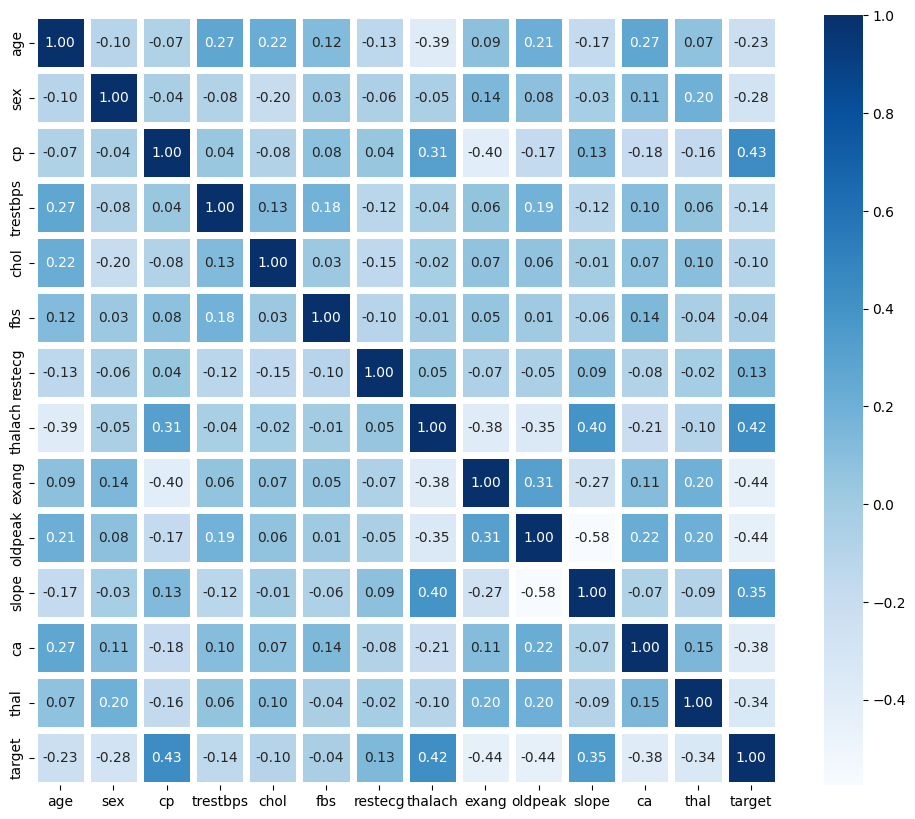

In [5]:
tabel_korelasi.corelation()

### 5. Visualisasi Data 

Akan saya visualisasikan data yang perlu diperhatikan untuk penilaian model.

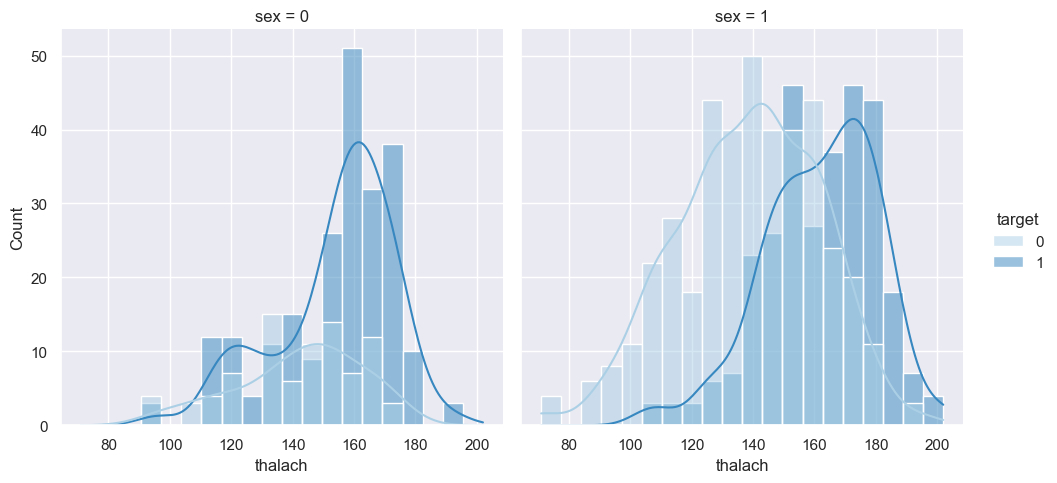

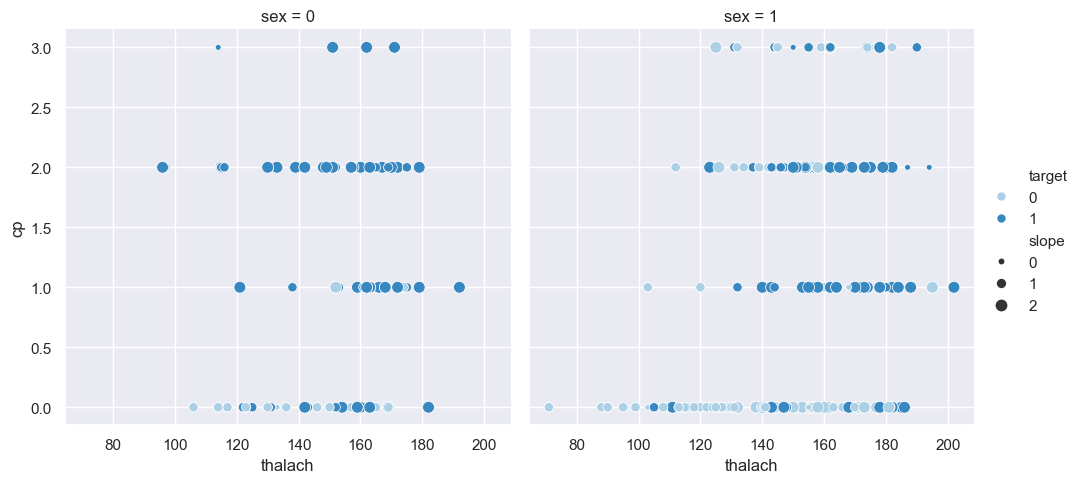

In [6]:
tabel_korelasi.displot(x="thalach", hue="target", col="sex")
tabel_korelasi.relplot(x="thalach", y="cp", col="sex", hue="target", size="slope")

Pada tabel diatas, ditemukan bahwa rata-rata pasien sakit memiliki thalach(Maximum Heart Rate Achieved) dikisaran 160-180. Kemudian kita crosskan dengan korelasi yang berhubungan dengan thalach. 

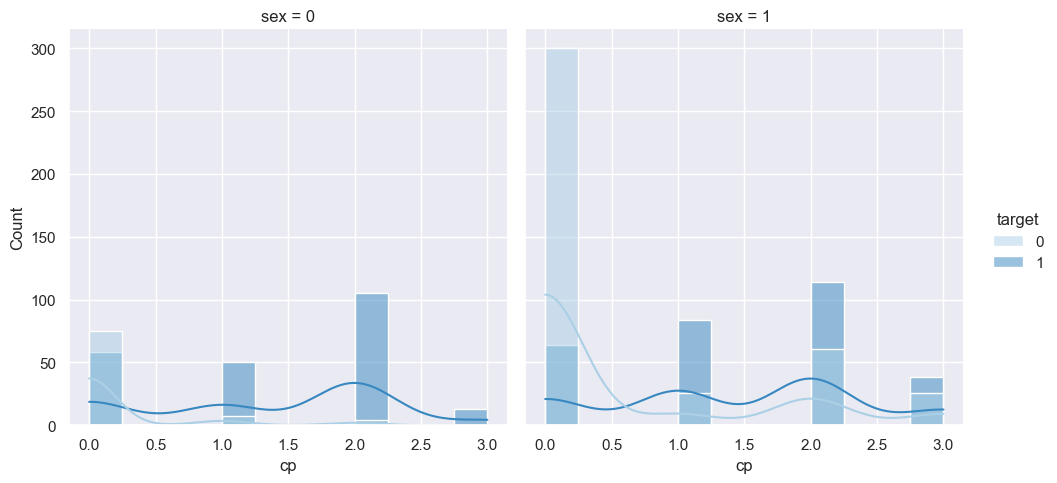

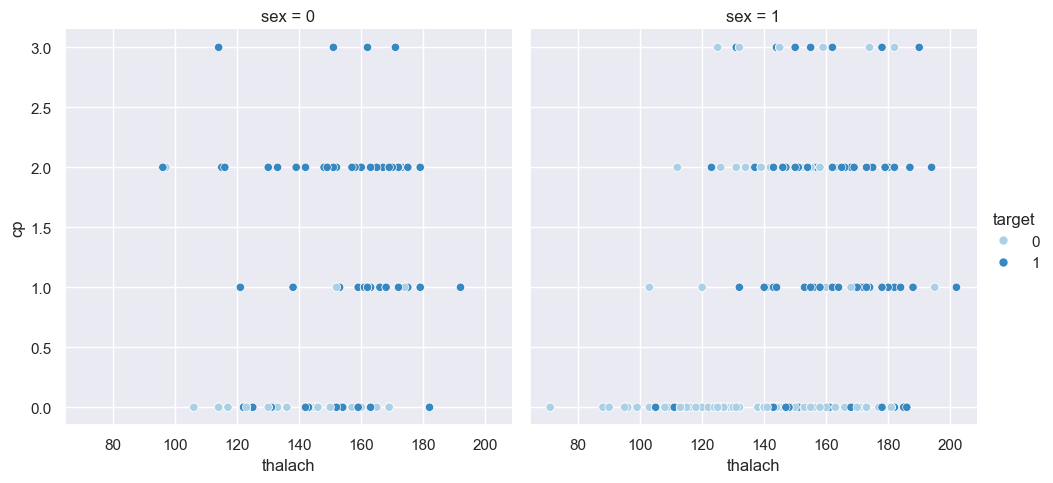

In [7]:
tabel_korelasi.displot(x="cp", hue="target", col="sex")
tabel_korelasi.relplot(x="thalach", y="cp", hue="target", col="sex")

Kemudian dapat diketahui pasien sakit rata-rata memiliki masalah di Atypical Angina dan Non-anginal Pain, kita crosskan juga dengan tabel thalach.

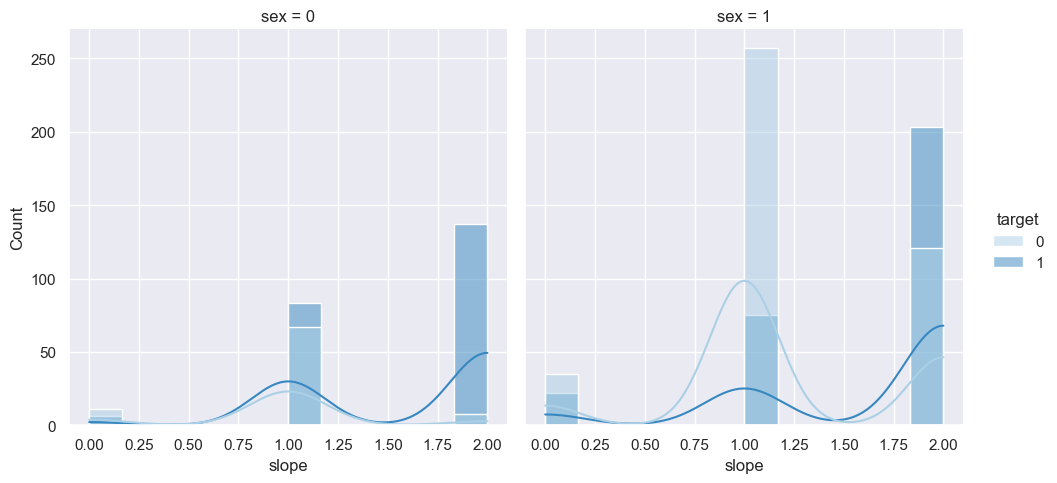

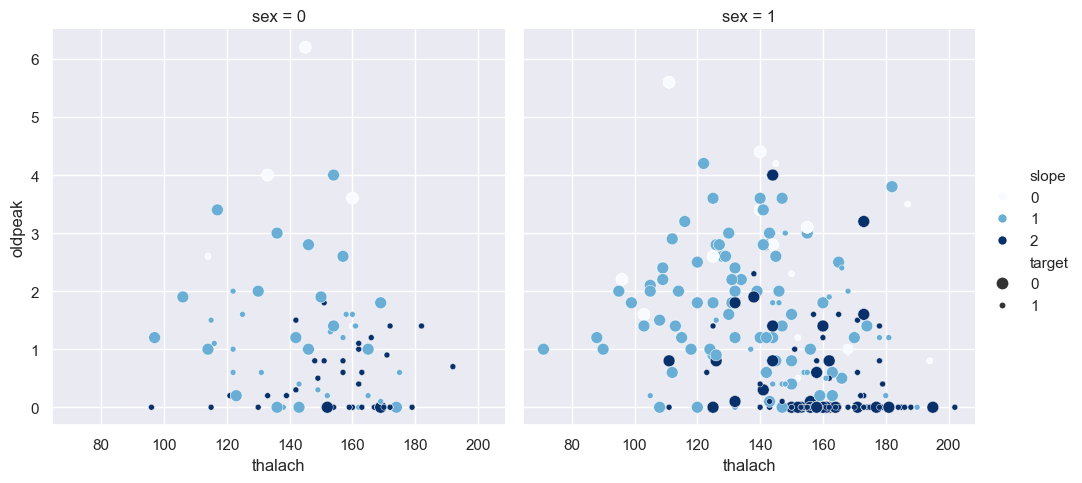

In [8]:
tabel_korelasi.displot(x="slope", hue="target", col="sex")
tabel_korelasi.relplot(x="thalach", y="oldpeak", hue="slope", col="sex", size="target")

Karena korelasi antara tabel slope, thalach dan oldpeak cukup kuat maka kita crosskan juga untuk mengetahui target sakit dan sehat.

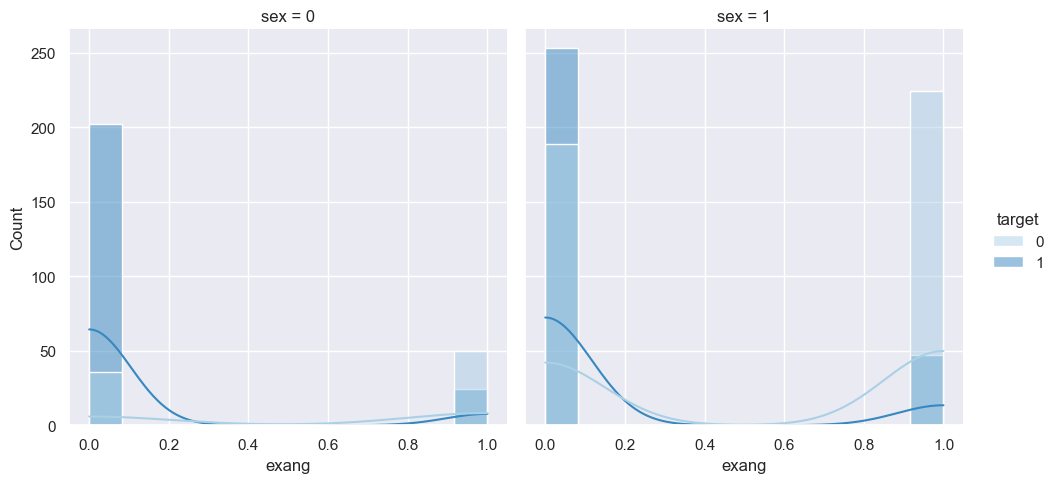

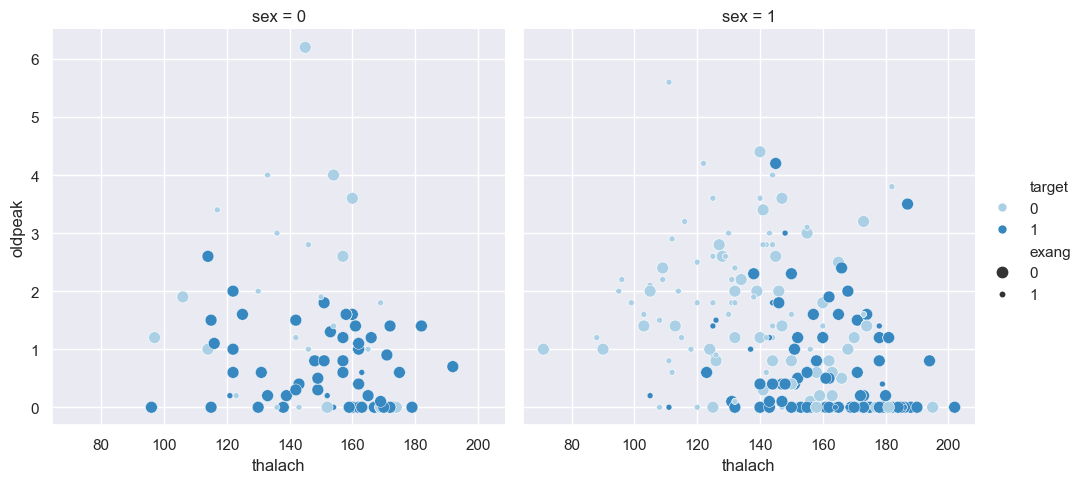

In [9]:
tabel_korelasi.displot(x="exang", hue="target", col="sex")
tabel_korelasi.relplot(x="thalach", y="oldpeak", hue="target", col="sex", size="exang")

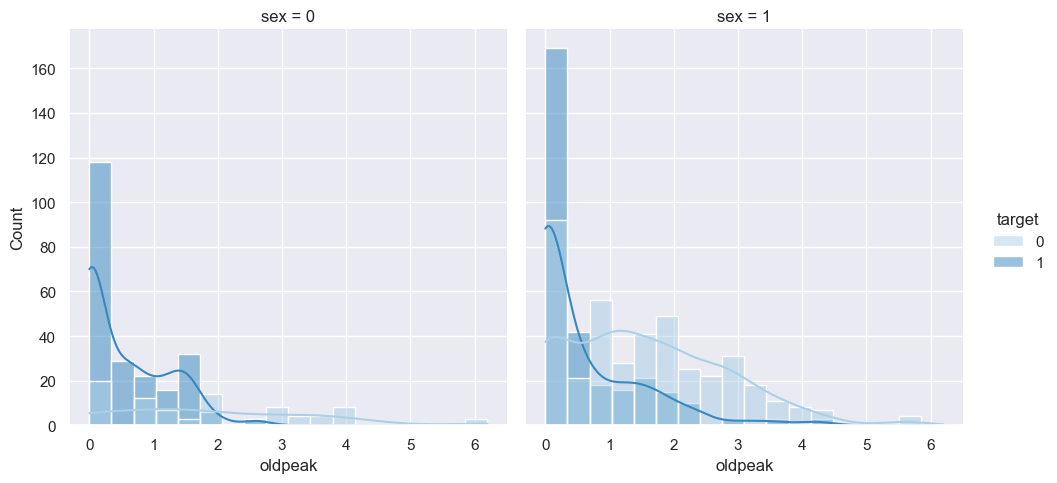

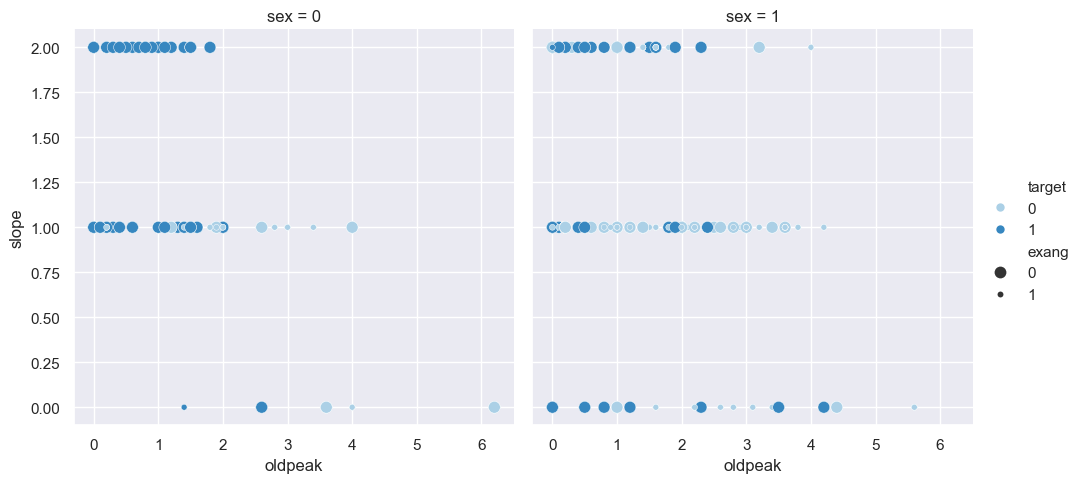

In [10]:
tabel_korelasi.displot(x="oldpeak", hue="target", col="sex")
tabel_korelasi.relplot(x="oldpeak", y="slope", hue="target", size="exang", col="sex")

### 6. Model Scikit Learn

Saya akan menggunakan model Random Forest Classifer. Pada model Random Forest logikanya adalah beberapa pohon yang mengambil keputusan dan melakukan voting berdasarkan suara terbanyak, model ini juga rawan overfitting maka harus melakukan setting parameter dan melakukan cross validasi score.

In [25]:
X = df_heart.drop(columns=['target'])
y = df_heart['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, max_depth=None,
    min_samples_split=2, random_state=0)
model.fit(X_train,y_train)
score = cross_val_score(model,X_train,y_train, cv=5)
scores = cross_val_score(model,X_test,y_test, cv=5)
score.mean()
scores.mean()





np.float64(0.8439024390243903)